<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/Hands_On_Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON – WEEK 4 | 2 Maret 2026**

In [ ]:
!pip install dedupe
!pip install yfinance

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.7/172.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.8/353.8 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 kB 4.3 MB/s eta 0:00:00
  Created wheel for affinegap:

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import dedupe
from dedupe import variables
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**A. Penanganan Missing Value**

Penanganan missing value adalah langkah krusial dalam proses data preprocessing yang bertujuan untuk meningkatkan
kualitas data sebelum digunakan dalam analisis atau pembangunan model machine learning. Missing value dapat
terjadi karena berbagai alasan, seperti kesalahan pengukuran, kekurangan data, atau proses pengumpulan data
yang tidak lengkap. Mengelola missing value dengan tepat dapat mencegah bias dalam analisis dan meningkatkan
akurasi model yang dibangun.

**A. 1. Menghapus Data dengan Missing Value**

**A. 1.1. Menghapus Baris dengan Missing Value**

Menghapus baris yang mengandung missing value adalah metode sederhana dan langsung untuk menangani missing data. Tujuannya adalah untuk memastikan bahwa analisis atau model machine learning yang dibangun hanya menggunakan data yang lengkap dan konsisten. Dengan menghapus baris yang memiliki satu atau lebih data yang hilang, kita dapat menghindari potensi bias atau kesalahan yang disebabkan oleh data yang tidak
lengkap.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:

* Proporsi Nilai Hilang Rendah: Jika hanya sedikit baris yang memiliki missing value, menghapus baris tersebut tidak akan secara signifikan mengurangi ukuran dataset atau menghilangkan informasi penting.
* Missing value Dapat Diabaikan: Tidak ada pola khusus dalam distribusi nilai hilang yang perlu dipertahankan, sehingga menghapus baris tidak akan menyebabkan bias dalam data.
* Keterbatasan Waktu atau Sumber Daya: Metode ini cepat dan mudah diimplementasikan tanpa memerlukan model atau algoritma tambahan.
* Data Missing Completely at Random (MCAR): Missing value tidak tergantung pada variabel lain dalam dataset, sehingga menghapus baris tidak akan mengintroduksi bias.

In [ ]:
#Ambil Data untuk penanganan missing values
file_path = "/content/drive/My Drive/Colab Notebooks/Data/MELBOURNE_HOUSE_PRICES_LESS.csv"
df = pd.read_csv(file_path)

df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63023 entries, 0 to 63022
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         63023 non-null  object 
 1   Address        63023 non-null  object 
 2   Rooms          63023 non-null  int64  
 3   Type           63023 non-null  object 
 4   Price          48433 non-null  float64
 5   Method         63023 non-null  object 
 6   SellerG        63023 non-null  object 
 7   Date           63023 non-null  object 
 8   Postcode       63023 non-null  int64  
 9   Regionname     63023 non-null  object 
 10  Propertycount  63023 non-null  int64  
 11  Distance       63023 non-null  float64
 12  CouncilArea    63023 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 6.3+ MB


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df["Postcode"] = df["Postcode"].astype("category")

In [ ]:
#@title cek missing value
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,14590
Method,0
SellerG,0
Date,0
Postcode,0
Regionname,0


In [ ]:
#@title Template script untuk menghapus baris dengan missing value
# Menghapus baris yang mengandung missing value
df_cleaned_row = df.dropna()

# Menampilkan jumlah baris sebelum dan sesudah penghapusan
print(f"Jumlah baris sebelum: {df.shape[0]}")
print(f"Jumlah baris setelah: {df_cleaned_row.shape[0]}")

Jumlah baris sebelum: 63023
Jumlah baris setelah: 48433


**A.1.2. Menghapus Kolom dengan Missing Value**

Menghapus kolom yang memiliki banyak missing value adalah metode untuk mengurangi kompleksitas data dan menghilangkan fitur yang mungkin tidak informatif atau terlalu lemah untuk analisis lebih lanjut. Dengan
menghapus kolom yang sebagian besar data-nya hilang, kita dapat menyederhanakan model dan fokus pada fitur-fitur yang memiliki kontribusi signifikan terhadap variabel target.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Proporsi missing value Tinggi: Kolom memiliki proporsi missing value yang sangat tinggi (misalnya, lebih dari 50%), sehingga mengisinya bisa sangat sulit dan tidak efisien.
* Keterkaitan Rendah dengan Target: Kolom tersebut tidak dianggap penting atau tidak memiliki korelasi yang kuat dengan variabel target dalam analisis.
* Reduksi Dimensi: Mengurangi jumlah fitur untuk meningkatkan efisiensi komputasi dan menghindari overfitting dalam model machine learning.
* Kesederhanaan Model: Menginginkan model yang lebih sederhana dengan lebih sedikit variabel untuk interpretasi yang lebih mudah.

In [ ]:
#@title Template script untuk menghapus kolom dengan missing value

# Menghapus kolom yang memiliki lebih dari 50% missing value
threshold = len(df) * 0.5
df_cleaned_column = df.dropna(axis=1, thresh=threshold)

# Menampilkan jumlah kolom sebelum dan sesudah penghapusan
print(f"Jumlah kolom sebelum: {df.shape[1]}")
print(f"Jumlah kolom setelah: {df_cleaned_column.shape[1]}")

Jumlah kolom sebelum: 13
Jumlah kolom setelah: 13


**A.1.3 Menghapus Sel Secara Selektif**

Menghapus sel secara selektif bertujuan untuk mengatasi missing value dengan cara yang lebih granular
dibandingkan dengan menghapus seluruh baris atau kolom. Metode ini berguna ketika missing value hanya terjadi pada beberapa sel dan tidak mempengaruhi keseluruhan struktur data secara signifikan. Dengan menghapus
sel yang hilang, kita dapat mempertahankan sebanyak mungkin informasi yang tersedia dalam dataset.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Missing Value Terdistribusi Secara Acak: missing value tidak terpusat pada satu atau beberapa baris atau kolom tertentu.
* Proporsi missing value Sedang: Proporsi missing value cukup rendah sehingga menghapus sel tidak akan mengurangi ukuran dataset secara signifikan.
* Data Missing Completely at Random (MCAR): missing value tidak tergantung pada variabel lain dalam dataset.
* Menghindari Bias dalam Data: Menghapus sel secara selektif dapat membantu menghindari bias yang mungkin terjadi jika menghapus seluruh baris atau kolom.

In [ ]:
#@title Template script untuk menghapus sel secara selektif

# Menghapus sel dengan missing value dengan menggantinya menjadi None atau NaN
df_cleaned = df.where(pd.notnull(df), None)

# Menampilkan dataframe yang telah dibersihkan
print(df_cleaned)

                 Suburb           Address  Rooms Type      Price Method  \
0            Abbotsford     49 Lithgow St      3    h  1490000.0      S   
1            Abbotsford     59A Turner St      3    h  1220000.0      S   
2            Abbotsford     119B Yarra St      3    h  1420000.0      S   
3            Aberfeldie        68 Vida St      3    h  1515000.0      S   
4          Airport West  92 Clydesdale Rd      2    h   670000.0      S   
...                 ...               ...    ...  ...        ...    ...   
63018     Roxburgh Park         3 Carr Pl      3    h   566000.0      S   
63019     Roxburgh Park       9 Parker Ct      3    h   500000.0      S   
63020     Roxburgh Park    5 Parkinson Wy      3    h   545000.0      S   
63021        Thomastown    3/1 Travers St      3    u        NaN     PI   
63022  Williams Landing       1 Diadem Wy      4    h        NaN     SP   

        SellerG        Date  Postcode             Regionname  Propertycount  \
0        Jellis   1/

**A.2. Mengisi Missing Value**

**A.2.1 Mengisi dengan Mean**

Mengisi missing value dengan mean (rata-rata) bertujuan untuk menggantikan missing value dengan nilai tengah dari distribusi data pada kolom tersebut. Metode ini sederhana dan efektif untuk data numerik yang memiliki distribusi simetris tanpa outlier yang signifikan. Dengan mengisi missing value dengan mean, kita dapat
mempertahankan ukuran dataset tanpa mengubah struktur data secara drastis.
Kapan harus digunakan
Metode ini paling sesuai digunakan ketika:
* Data Numerik: Kolom yang memiliki missing value adalah data numerik.
* Distribusi Simetris: Data memiliki distribusi yang simetris tanpa outlier yang signifikan, sehingga mean
merupakan representasi yang baik dari pusat distribusi.
* Proporsi missing value Rendah: Proporsi missing value cukup rendah sehingga mengisi dengan mean tidak akan mengubah variansi data secara signifikan.
* Tidak Ada Keterkaitan Antar Fitur yang Kuat: missing value tidak tergantung pada fitur lain yang bisa digunakan untuk imputasi lebih kompleks.

In [ ]:
#@title Template script untuk mengisi missing value dengan mean

# Mengisi missing value dengan mean pada semua kolom numerik
means = df.mean(numeric_only=True)
df_imputed_mean = df.fillna(means)

# Menampilkan hasil
print(df_imputed_mean)

                 Suburb           Address  Rooms Type         Price Method  \
0            Abbotsford     49 Lithgow St      3    h  1.490000e+06      S   
1            Abbotsford     59A Turner St      3    h  1.220000e+06      S   
2            Abbotsford     119B Yarra St      3    h  1.420000e+06      S   
3            Aberfeldie        68 Vida St      3    h  1.515000e+06      S   
4          Airport West  92 Clydesdale Rd      2    h  6.700000e+05      S   
...                 ...               ...    ...  ...           ...    ...   
63018     Roxburgh Park         3 Carr Pl      3    h  5.660000e+05      S   
63019     Roxburgh Park       9 Parker Ct      3    h  5.000000e+05      S   
63020     Roxburgh Park    5 Parkinson Wy      3    h  5.450000e+05      S   
63021        Thomastown    3/1 Travers St      3    u  9.978982e+05     PI   
63022  Williams Landing       1 Diadem Wy      4    h  9.978982e+05     SP   

        SellerG        Date  Postcode             Regionname  P

**A.2.2 Mengisi dengan Median**

Mengisi missing value dengan median bertujuan untuk menggantikan missing values dengan nilai tengah dari distribusi data pada kolom tersebut. Metode ini lebih tahan terhadap outlier dibandingkan dengan pengisian
menggunakan mean, sehingga lebih cocok untuk data numerik yang memiliki distribusi miring atau terdapat outlier yang signifikan.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data Numerik: Kolom yang memiliki missing values adalah data numerik.
* Distribusi Miring atau Dengan Outlier: Data memiliki distribusi yang tidak simetris atau terdapat outlier yang dapat mempengaruhi mean.
* Proporsi missing values Rendah hingga Sedang: Proporsi missing values cukup rendah hingga sedang sehingga mengisi dengan median tidak akan mengubah bentuk distribusi data secara drastis.
* Tidak Ada Keterkaitan Antar Fitur yang Kuat: missing values tidak tergantung pada fitur lain yang bisa digunakan untuk imputasi lebih kompleks.

In [ ]:
#@title Template script untuk mengisi missing value dengan median

# Mengisi missing value dengan median pada semua kolom numerik
imputer = df.median(numeric_only=True)
df_imputed_median = df.fillna(imputer)

# Menampilkan hasil
print(df_imputed_median)

                 Suburb           Address  Rooms Type      Price Method  \
0            Abbotsford     49 Lithgow St      3    h  1490000.0      S   
1            Abbotsford     59A Turner St      3    h  1220000.0      S   
2            Abbotsford     119B Yarra St      3    h  1420000.0      S   
3            Aberfeldie        68 Vida St      3    h  1515000.0      S   
4          Airport West  92 Clydesdale Rd      2    h   670000.0      S   
...                 ...               ...    ...  ...        ...    ...   
63018     Roxburgh Park         3 Carr Pl      3    h   566000.0      S   
63019     Roxburgh Park       9 Parker Ct      3    h   500000.0      S   
63020     Roxburgh Park    5 Parkinson Wy      3    h   545000.0      S   
63021        Thomastown    3/1 Travers St      3    u   830000.0     PI   
63022  Williams Landing       1 Diadem Wy      4    h   830000.0     SP   

        SellerG        Date  Postcode             Regionname  Propertycount  \
0        Jellis   1/

**A.2.3 Mengisi dengan Mode**

Mengisi missing value dengan mode bertujuan untuk menggantikan missing values dengan nilai yang paling sering muncul dalam kolom tersebut. Metode ini cocok untuk data kategorikal atau data numerik yang memiliki nilai
paling sering muncul yang representatif. Dengan mengisi missing value dengan mode, kita dapat mempertahankan distribusi frekuensi dari data asli.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data Kategorikal: Kolom yang memiliki missing value adalah data kategorikal.
* Data Numerik dengan Mode Jelas: Data numerik memiliki nilai mode yang jelas dan representatif dari distribusi data.
* Proporsi missing value Rendah hingga Sedang: Proporsi missing value cukup rendah hingga sedang sehingga mengisi dengan mode tidak akan mengubah distribusi data secara drastis.
* Tidak Ada Keterkaitan Antar Fitur yang Kuat: missing value tidak tergantung pada fitur lain yang bisa digunakan untuk imputasi lebih kompleks.

In [ ]:
# Template script untuk mengisi missing value dengan mode menggunakan pandas

# Mengisi missing value dengan mode pada semua kolom
imputer = df.mode().iloc[0]
df_imputed_mode = df.fillna(imputer)

# Menampilkan hasil
print(df_imputed_mode)

                 Suburb           Address  Rooms Type      Price Method  \
0            Abbotsford     49 Lithgow St      3    h  1490000.0      S   
1            Abbotsford     59A Turner St      3    h  1220000.0      S   
2            Abbotsford     119B Yarra St      3    h  1420000.0      S   
3            Aberfeldie        68 Vida St      3    h  1515000.0      S   
4          Airport West  92 Clydesdale Rd      2    h   670000.0      S   
...                 ...               ...    ...  ...        ...    ...   
63018     Roxburgh Park         3 Carr Pl      3    h   566000.0      S   
63019     Roxburgh Park       9 Parker Ct      3    h   500000.0      S   
63020     Roxburgh Park    5 Parkinson Wy      3    h   545000.0      S   
63021        Thomastown    3/1 Travers St      3    u   600000.0     PI   
63022  Williams Landing       1 Diadem Wy      4    h   600000.0     SP   

        SellerG        Date  Postcode             Regionname  Propertycount  \
0        Jellis   1/

**A.2.7 Imputasi Regresi**


Imputasi regresi bertujuan untuk menggantikan *missing values* dengan memprediksi nilai tersebut berdasarkan hubungan linear atau non-linear dengan fitur lain dalam dataset. Metode ini menggunakan model regresi untuk
memprediksi *missing values*, sehingga memberikan imputasi yang lebih akurat dibandingkan dengan metode sederhana seperti mean atau median.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Hubungan Linier atau Non-Linier yang Kuat: Data memiliki hubungan yang jelas antara fitur yang memiliki nilai hilang dengan fitur lainnya.
* Data Numerik: Imputasi regresi lebih cocok untuk data numerik.
* Proporsi Nilai Hilang Rendah hingga Sedang: Proporsi nilai hilang cukup rendah hingga sedang sehingga model regresi dapat dilatih dengan baik.
* Tidak Ada Multikolinearitas yang Tinggi: Multikolinearitas dapat mempengaruhi performa model regresi.
* Dataset yang Cukup Besar: Metode ini memerlukan data yang cukup untuk melatih model regresi secara akurat.

In [ ]:
from sklearn.linear_model import LinearRegression

# Re-load data to ensure 'Price' column has missing values for this example
# df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
# df["Postcode"] = df["Postcode"].astype("category")

# Select only numeric columns for features, excluding 'Price'
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols.drop("Price")

# Separate data into complete and missing based on 'Price' column
df_complete = df[df["Price"].notna()]
df_missing = df[df["Price"].isna()]

X_train = df_complete[num_cols]
y_train = df_complete["Price"]

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict missing 'Price' values
# Only predict if there are actual missing values to predict
if not df_missing.empty:
    df.loc[df["Price"].isna(), "Price"] = model.predict(df_missing[num_cols])

print(df["Price"])

0        1.490000e+06
1        1.220000e+06
2        1.420000e+06
3        1.515000e+06
4        6.700000e+05
             ...     
63018    5.660000e+05
63019    5.000000e+05
63020    5.450000e+05
63021    8.198588e+05
63022    1.036909e+06
Name: Price, Length: 63023, dtype: float64


**A.2.4 Mengisi dengan Forward Fill**

Mengisi *missing values* dengan metode* forward fill* bertujuan untuk menggantikan *missing values* dengan nilai yang sebelumnya hadir dalam kolom tersebut. Metode ini mempertahankan tren dan pola temporal dalam
data, terutama untuk data *time series*, dengan mengisi *missing values* berdasarkan informasi historis.

**Kapan harus digunakan**
Metode ini paling sesuai digunakan ketika:
* Data Time Series: Data memiliki urutan temporal yang memungkinkan nilai sebelumnya digunakan sebagai pengganti.
* Keterkaitan Antar Waktu: Nilai di waktu sebelumnya dianggap relevan dan representatif untuk nilai yang hilang di waktu berikutnya.
* Proporsi Nilai Hilang Sedang hingga Tinggi: Proporsi nilai hilang cukup tinggi sehingga metode lain seperti mean atau median tidak efektif.
* Menghindari Pengubahan Distribusi Data: Forward fill tidak mengubah distribusi data secara signifikan karena hanya menyalin nilai yang ada.

In [ ]:
import yfinance as yf
import pandas as pd

lq45 = [
    "ASII.JK","TLKM.JK","BBRI.JK","BMRI.JK","BBCA.JK",
    "UNVR.JK","ANTM.JK","KLBF.JK","CPIN.JK","INDF.JK",
    "ICBP.JK","EXCL.JK","PTBA.JK","PGAS.JK"
]

data = yf.download(
    lq45,
    start="2013-01-01",
    end="2025-12-31",
    auto_adjust=True,
    group_by='ticker'
)

# Ambil Close saja
datasaham = pd.DataFrame({
    ticker: data[ticker]['Close'] for ticker in lq45
})

datasaham.head()

[*********************100%***********************]  14 of 14 completed


,ASII.JK,TLKM.JK,BBRI.JK,BMRI.JK,BBCA.JK,UNVR.JK,ANTM.JK,KLBF.JK,CPIN.JK,INDF.JK,ICBP.JK,EXCL.JK,PTBA.JK,PGAS.JK
Date,,,,,,,,,,,,,,
2013-01-02,4172.052246,1013.468384,746.198242,1235.222778,1452.197266,2970.154785,861.336609,832.187988,2975.801514,3733.549805,3090.540527,4510.875000,879.370544,2438.924072
2013-01-03,4366.747559,1019.130249,762.074829,1227.736450,1460.176147,3004.137695,880.765198,856.193420,2934.470703,3765.734863,3090.540527,4550.444336,897.967468,2491.944824
2013-01-04,4366.747559,1030.454102,777.951355,1235.222778,1444.218262,2956.561035,874.288940,832.187988,2955.135986,3830.107178,3090.540527,4550.444336,892.654175,2478.689453
2013-01-07,4311.120117,1041.777588,783.243530,1227.736450,1468.155640,2949.764893,867.812866,824.186218,2810.479004,3765.734863,3071.224609,4510.875000,884.683960,2399.159668
2013-01-08,4255.493652,1036.115601,793.828064,1250.195190,1460.176147,2942.967773,893.717651,816.184448,2934.470703,3862.292480,3129.172119,4510.875000,879.370544,2399.159668


In [ ]:
datasaham.isna().sum()

,0
ASII.JK,1
TLKM.JK,1
BBRI.JK,0
BMRI.JK,0
BBCA.JK,0
UNVR.JK,0
ANTM.JK,0
KLBF.JK,0
CPIN.JK,1
INDF.JK,0


In [ ]:
missing_rows = datasaham[datasaham.isna().any(axis=1)]
missing_rows.index

DatetimeIndex(['2019-06-19'], dtype='datetime64[ns]', name='Date', freq=None)

In [ ]:
#@title Template script untuk mengisi missing values dengan forward fill menggunakan pandas

# Mengisi missing value dengan forward fill
data_imputed_ff = datasaham.fillna(method='ffill')

# Menampilkan hasil
print(data_imputed_ff)

                ASII.JK      TLKM.JK      BBRI.JK      BMRI.JK      BBCA.JK  \
Date                                                                          
2013-01-02  4172.052246  1013.468384   746.198242  1235.222778  1452.197266   
2013-01-03  4366.747559  1019.130249   762.074829  1227.736450  1460.176147   
2013-01-04  4366.747559  1030.454102   777.951355  1235.222778  1444.218262   
2013-01-07  4311.120117  1041.777588   783.243530  1227.736450  1468.155640   
2013-01-08  4255.493652  1036.115601   793.828064  1250.195190  1460.176147   
...                 ...          ...          ...          ...          ...   
2025-12-22  6575.000000  3470.000000  3623.724854  4999.009766  8175.000000   
2025-12-23  6500.000000  3470.000000  3633.362549  4950.000000  8025.000000   
2025-12-24  6625.000000  3460.000000  3633.362549  4950.000000  8025.000000   
2025-12-29  6675.000000  3490.000000  3643.000000  4974.504883  8025.000000   
2025-12-30  6700.000000  3480.000000  3660.000000  4

/tmp/ipython-input-242/1409643878.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_imputed_ff = datasaham.fillna(method='ffill')


In [ ]:
data_imputed_ff.isna().sum()

,0
ASII.JK,0
TLKM.JK,0
BBRI.JK,0
BMRI.JK,0
BBCA.JK,0
UNVR.JK,0
ANTM.JK,0
KLBF.JK,0
CPIN.JK,0
INDF.JK,0


**A.2.5 Mengisi dengan Backward Fill**

Mengisi *missing values* dengan metode *backward fill *bertujuan untuk menggantikan *missing values* dengan nilai yang berikutnya hadir dalam kolom tersebut. Metode ini mempertahankan tren dan pola temporal dalam data, terutama untuk data *time series*, dengan mengisi nilai hilang berdasarkan informasi yang akan datang.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data Time Series: Data memiliki urutan temporal yang memungkinkan nilai berikutnya digunakan sebagai pengganti.
* Keterkaitan Antar Waktu: Nilai di waktu berikutnya dianggap relevan dan representatif untuk nilai yang hilang di waktu sebelumnya.
* Proporsi Nilai Hilang Sedang hingga Tinggi: Proporsi nilai hilang cukup tinggi sehingga metode lain seperti mean atau median tidak efektif
* Menghindari Pengubahan Distribusi Data: Backward fill tidak mengubah distribusi data secara signifikan karena hanya menyalin nilai yang ada.

In [ ]:
#@title Template script untuk mengisi nilai hilang dengan backward fill menggunakan pandas

# Mengisi nilai hilang dengan backward fill
data_imputed_bf = datasaham.fillna(method='bfill')

# Menampilkan hasil
print(data_imputed_bf)

                ASII.JK      TLKM.JK      BBRI.JK      BMRI.JK      BBCA.JK  \
Date                                                                          
2013-01-02  4172.052246  1013.468384   746.198242  1235.222778  1452.197266   
2013-01-03  4366.747559  1019.130249   762.074829  1227.736450  1460.176147   
2013-01-04  4366.747559  1030.454102   777.951355  1235.222778  1444.218262   
2013-01-07  4311.120117  1041.777588   783.243530  1227.736450  1468.155640   
2013-01-08  4255.493652  1036.115601   793.828064  1250.195190  1460.176147   
...                 ...          ...          ...          ...          ...   
2025-12-22  6575.000000  3470.000000  3623.724854  4999.009766  8175.000000   
2025-12-23  6500.000000  3470.000000  3633.362549  4950.000000  8025.000000   
2025-12-24  6625.000000  3460.000000  3633.362549  4950.000000  8025.000000   
2025-12-29  6675.000000  3490.000000  3643.000000  4974.504883  8025.000000   
2025-12-30  6700.000000  3480.000000  3660.000000  4

/tmp/ipython-input-242/3354685016.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_imputed_bf = datasaham.fillna(method='bfill')


**A.2.6 Menggunakan Interpolasi Linear**

Menggunakan interpolasi linear bertujuan untuk menggantikan *missing values *dengan menghitung nilai rata-rata antara dua titik data terdekat yang ada di sekitar nilai yang hilang. Metode ini efektif untuk data yang memiliki tren linier atau perubahan gradual antar titik data, seperti data *time series*.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data *Time Series* atau Terurut: Data memiliki urutan temporal atau urutan tertentu yang memungkinkan interpolasi antara titik-titik data.
* Tren Linier atau Gradual: Data menunjukkan tren linier atau perubahan yang gradual antar titik data.
* Proporsi *missing* *values* Sedang: Proporsi *missing values* cukup rendah hingga sedang sehingga interpolasi dapat dilakukan secara efektif.
* Tidak Ada Outlier yang Signifikan: Outlier dapat mempengaruhi hasil interpolasi secara negatif.

In [ ]:
# Pastikan index adalah datetime (biasanya sudah otomatis dari yfinance)
datasaham.index = pd.to_datetime(datasaham.index)

# Urutkan berdasarkan waktu
datasaham = datasaham.sort_index()

# Mengisi missing value dengan interpolasi linear (berdasarkan waktu)
datasaham_imputed = datasaham.interpolate(method='linear')

# Menampilkan hasil
print(datasaham_imputed.head())

                ASII.JK      TLKM.JK     BBRI.JK      BMRI.JK      BBCA.JK  \
Date                                                                         
2013-01-02  4172.052246  1013.468384  746.198242  1235.222778  1452.197266   
2013-01-03  4366.747559  1019.130249  762.074829  1227.736450  1460.176147   
2013-01-04  4366.747559  1030.454102  777.951355  1235.222778  1444.218262   
2013-01-07  4311.120117  1041.777588  783.243530  1227.736450  1468.155640   
2013-01-08  4255.493652  1036.115601  793.828064  1250.195190  1460.176147   

                UNVR.JK     ANTM.JK     KLBF.JK      CPIN.JK      INDF.JK  \
Date                                                                        
2013-01-02  2970.154785  861.336609  832.187988  2975.801514  3733.549805   
2013-01-03  3004.137695  880.765198  856.193420  2934.470703  3765.734863   
2013-01-04  2956.561035  874.288940  832.187988  2955.135986  3830.107178   
2013-01-07  2949.764893  867.812866  824.186218  2810.479004  3765.7

**B. Penanganan Data Duplikat**

Penanganan data duplikat adalah langkah penting dalam proses data *preprocessing* yang bertujuan untuk mengidentifikasi dan menghilangkan data yang sama atau serupa dalam dataset. Duplikat dapat mengakibatkan
bias dalam analisis dan model *machine learning*, sehingga pengelolaannya perlu dilakukan dengan cermat untuk memastikan kualitas data yang optimal.

**B.1 Mengidentifikasi Duplikat**

Mengidentifikasi duplikat adalah langkah awal dalam penanganan data duplikat yang melibatkan pencarian baris atau entitas yang sama atau sangat mirip dalam dataset. Proses ini dapat dilakukan berdasarkan semua
fitur, subset fitur, menggunakan algoritma deduplication, atau similarity metrics untuk menemukan duplikat.

**B.1.1 Berdasarkan Semua Fitur**

Mengidentifikasi duplikat berdasarkan semua fitur bertujuan untuk menemukan baris yang sepenuhnya identik dalam seluruh kolom dataset. Metode ini efektif untuk dataset yang memiliki identifikasi unik dan tidak
mengandung kesalahan atau variasi kecil dalam data.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Dataset dengan Identifikasi Unik: Data memiliki identifikasi yang unik dan duplikat dapat diidentifikasi secara jelas.
* Tidak Ada Kesalahan Pengukuran atau Variasi: Data bebas dari kesalahan pengukuran atau variasi
kecil yang dapat menyebabkan duplikat tidak sepenuhnya identik.
• Proporsi Duplikat Rendah hingga Sedang: Proporsi duplikat cukup rendah hingga sedang sehingga
identifikasi dan penghapusan dapat dilakukan secara efektif tanpa kehilangan informasi penting.

In [ ]:
#@title Template script untuk mengidentifikasi duplikat berdasarkan semua fitur

# Mengidentifikasi duplikat berdasarkan semua fitur
duplicate_rows = df[df.duplicated()]
# Menampilkan baris duplikat
print("Baris Duplikat:")
print(duplicate_rows)

Baris Duplikat:
              Suburb         Address  Rooms Type         Price Method  \
8042   Fitzroy North  5/16 Taplin St      2    h  1.010000e+06     SP   
33942     Nunawading   1/7 Lilian St      3    t  8.829100e+05     SP   

        SellerG        Date  Postcode             Regionname  Propertycount  \
8042   Woodards   5/05/2018      3068  Northern Metropolitan           6244   
33942    Jellis  17/06/2017      3131   Eastern Metropolitan           4973   

       Distance              CouncilArea  
8042        3.6    Moreland City Council  
33942      15.4  Manningham City Council  


**B.1.2 Berdasarkan Subset Fitur**

Mengidentifikasi duplikat berdasarkan subset fitur bertujuan untuk menemukan baris yang memiliki kesamaan pada kolom tertentu, meskipun mungkin berbeda pada kolom lainnya. Metode ini berguna ketika
hanya sebagian fitur yang relevan untuk menentukan keunikan entitas dalam dataset.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Identifikasi Berdasarkan Fitur Tertentu: Duplikat ditentukan berdasarkan kombinasi beberapa kolom yang dianggap relevan.
* Variasi pada Fitur Lain: Data mungkin memiliki variasi atau kesalahan pada kolom yang tidak digunakan untuk identifikasi duplikat.
* Proporsi Duplikat Rendah hingga Sedang: Proporsi duplikat cukup rendah hingga sedang sehingga identifikasi dan penghapusan dapat dilakukan secara efektif.

In [ ]:
#@title Template script untuk mengidentifikasi duplikat berdasarkan subset fitur

# Mengidentifikasi duplikat berdasarkan subset fitur

duplicate_rows = df[df.duplicated(subset=['Suburb', 'Address', 'Date'])]

print("Baris Duplikat berdasarkan 'Suburb', 'Address', dan 'Date':")
print(duplicate_rows)

Baris Duplikat berdasarkan 'Suburb', 'Address', dan 'Date':
               Suburb           Address  Rooms Type         Price Method  \
7498          Highett  39a Middleton St      1    u  5.820000e+05      S   
7663    Sunshine West      124 Hilma St      5    h  1.631967e+06     PI   
8042    Fitzroy North    5/16 Taplin St      2    h  1.010000e+06     SP   
10547     Templestowe     1/23 Hakea St      2    h  5.148197e+05     PN   
25460     Forest Hill     15 Sandon Cct      2    h  7.620100e+05     SP   
29149        Bundoora     9 Bendoran Cr      4    h  6.300000e+05      S   
33942      Nunawading     1/7 Lilian St      3    t  8.829100e+05     SP   
34441       Maidstone     3/29 Burns St      2    t  6.720000e+05     SP   
41197        Brighton     4/4 Dudley St      3    u  1.113853e+06     PN   
50093          Toorak    2/9 Tintern Av      3    u  8.510000e+05     SP   
53840       Melbourne      505/1 Roy St      2    u  9.893110e+05      S   
56893           Lalor     10

**B.2.1 Menghapus Baris Duplikat Pertama**

Menghapus baris duplikat pertama bertujuan untuk mempertahankan baris pertama dari setiap set duplikat
dan menghapus baris duplikat berikutnya. Metode ini berguna untuk mempertahankan data yang muncul
pertama kali dan menghapus entri yang redundan.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data Tidak Berurutan: Urutan data tidak mempengaruhi pentingnya setiap entri.
* Ingin Mempertahankan Entri Pertama: Entitas pertama dianggap paling representatif atau paling relevan.
* Proporsi Duplikat Rendah hingga Sedang: Proporsi duplikat cukup rendah hingga sedang sehingga
penghapusan tidak mengurangi data secara signifikan.

In [ ]:
#@title Template script untuk menghapus baris duplikat pertama

# Menghapus duplikat dan mempertahankan entri pertama
df_cleaned = df.drop_duplicates(keep='first')
# Menampilkan jumlah baris sebelum dan sesudah penghapusan
print(f"Jumlah baris sebelum: {df.shape[0]}")
print(f"Jumlah baris setelah: {df_cleaned.shape[0]}")

Jumlah baris sebelum: 63023
Jumlah baris setelah: 63021


**B.2.2 Menghapus Baris Duplikat Terakhir**

Menghapus baris duplikat terakhir bertujuan untuk mempertahankan baris terakhir dari setiap set dup-
likat dan menghapus baris duplikat sebelumnya. Metode ini berguna ketika entri terakhir dianggap paling
representatif atau paling relevan.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data Berurutan: Urutan data penting dan entri terakhir lebih relevan.
* Ingin Mempertahankan Entri Terakhir: Entitas terakhir dianggap paling representatif atau paling
relevan.
* Proporsi Duplikat Rendah hingga Sedang: Proporsi duplikat cukup rendah hingga sedang sehingga
penghapusan tidak mengurangi data secara signifikan.

In [ ]:
#@title Template script untuk menghapus baris duplikat terakhir

# Menghapus duplikat dan mempertahankan entri terakhir
df_cleaned = df.drop_duplicates(keep='last')
# Menampilkan jumlah baris sebelum dan sesudah penghapusan
print(f"Jumlah baris sebelum: {df.shape[0]}")
print(f"Jumlah baris setelah: {df_cleaned.shape[0]}")

Jumlah baris sebelum: 63023
Jumlah baris setelah: 63021


menghapus duplikat berdasarkan, Suburb, Address, Date (subset fitur)

In [ ]:
df_subsetfitur = df.drop_duplicates(subset=['Suburb', 'Address', 'Date'])
# Menampilkan jumlah baris sebelum dan sesudah penghapusan
print(f"Jumlah baris sebelum: {df.shape[0]}")
print(f"Jumlah baris setelah: {df_subsetfitur.shape[0]}")

Jumlah baris sebelum: 63023
Jumlah baris setelah: 63009


**C. Identifikasi dan Penanganan Outlier**

Outlier adalah data yang berbeda secara signifikan dari sebagian besar data lainnya dalam dataset. Identifikasi
dan penanganan outlier merupakan langkah penting dalam proses data preprocessing karena outlier dapat
mempengaruhi analisis statistik dan performa model machine learning. Outlier dapat muncul karena kesalahan
pengukuran, pencatatan data yang tidak akurat, atau variasi alami dalam data. Mengelola outlier dengan tepat
dapat meningkatkan akurasi model dan keandalan hasil analisis.

**C.1 Identifikasi Outlier**
Identifikasi outlier adalah proses untuk mendeteksi data yang menyimpang dari pola umum dalam dataset.
Terdapat berbagai metode untuk mengidentifikasi outlier, baik secara univariat maupun multivariat, serta
menggunakan teknik statistik, visualisasi, dan algoritma machine learning.

**C.1.1 Menggunakan Z-Score**

Z-Score digunakan untuk mengukur seberapa jauh sebuah data dari rata-rata dalam satuan standar deviasi.
Metode ini membantu dalam mengidentifikasi data yang berada di luar rentang normal yang ditetapkan.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data mengikuti distribusi normal.
* Mengidentifikasi outlier univariat.
* Mencari nilai yang ekstrem dalam data kontinu.

In [ ]:
#Ambil Data untuk deteksi outlier
file_path = "/content/drive/My Drive/Colab Notebooks/Data/clv_data.csv"
dfclv = pd.read_csv(file_path)

dfclv.head()

,Unnamed: 0,id,age,gender,income,days_on_platform,city,purchases
0,0,0,NaN,Male,126895,14.0,San Francisco,0
1,1,1,NaN,Male,161474,14.0,Tokyo,0
2,2,2,24.0,Male,104723,34.0,London,1
3,3,3,29.0,Male,43791,28.0,London,2
4,4,4,18.0,Female,132181,26.0,London,2


In [ ]:
dfclv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5000 non-null   int64  
 1   id                5000 non-null   int64  
 2   age               2554 non-null   float64
 3   gender            5000 non-null   object 
 4   income            5000 non-null   int64  
 5   days_on_platform  4859 non-null   float64
 6   city              5000 non-null   object 
 7   purchases         5000 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 312.6+ KB


In [ ]:
#@title Template script untuk mengidentifikasi outlier menggunakan Z-Score dengan scipy

from scipy import stats

# Misalkan df adalah dataframe Anda dan 'income' adalah kolom yang ingin dianalisis
z_scores = stats.zscore(dfclv['income'])
abs_z_scores = abs(z_scores)
threshold = 3
outliers = dfclv[abs_z_scores > threshold]
print(f"Jumlah outlier: {outliers.shape[0]}")
print(outliers)

Jumlah outlier: 41
      Unnamed: 0    id   age  gender  income  days_on_platform           city  \
96            96    96   NaN    Male  279792              36.0         London   
200          200   200  46.0  Female  309902              51.0          Tokyo   
249          249   249   NaN  Female  265599              58.0         London   
423          423   423  43.0  Female  263840              49.0         London   
455          455   455  13.0    Male  372813               NaN          Miami   
621          621   621   NaN    Male  263497               2.0  San Francisco   
816          816   816  28.0    Male  317779              12.0          Miami   
838          838   838   NaN  Female  324518              35.0  New York City   
944          944   944  34.0    Male  364025              35.0  New York City   
1145        1145  1145  33.0    Male  366344               7.0  San Francisco   
1217        1217  1217  44.0  Female  276225              35.0  San Francisco   
1241     

**C.1.2 Menggunakan IQR (Interquartile Range)**

IQR digunakan untuk mengukur rentang tengah data dan mendeteksi outlier berdasarkan jarak antara
kuartil pertama (Q1) dan kuartil ketiga (Q3). Metode ini efektif untuk data yang tidak mengikuti distribusi
normal.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data tidak mengikuti distribusi normal.
* Mengidentifikasi outlier univariat.
* Data memiliki distribusi yang simetris atau asimetris.
Template script


In [ ]:
#@title Template script untuk mengidentifikasi outlier menggunakan IQR

# Misalkan df adalah dataframe Anda dan 'income' adalah kolom yang ingin dianalisis
Q1 = dfclv['income'].quantile(0.25)
Q3 = dfclv['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dfclv[(dfclv['income'] < lower_bound) | (dfclv['income'] > upper_bound)]

print(f"Jumlah outlier: {outliers.shape[0]}")
print(outliers)

Jumlah outlier: 77
      Unnamed: 0    id   age  gender  income  days_on_platform           city  \
50            50    50  36.0    Male  255965              22.0          Tokyo   
96            96    96   NaN    Male  279792              36.0         London   
200          200   200  46.0  Female  309902              51.0          Tokyo   
249          249   249   NaN  Female  265599              58.0         London   
423          423   423  43.0  Female  263840              49.0         London   
...          ...   ...   ...     ...     ...               ...            ...   
4198        4198  4198   NaN  Female  273579              51.0  New York City   
4383        4383  4383  11.0    Male  308439              25.0  New York City   
4723        4723  4723  27.0    Male  264791              14.0  New York City   
4778        4778  4778  11.0    Male  282909              25.0          Miami   
4859        4859  4859  16.0  Female  299191              25.0          Miami   

      pu

**C.1.3 Menggunakan Boxplot**

Boxplot adalah alat visualisasi yang digunakan untuk menggambarkan distribusi data dan mendeteksi outlier
berdasarkan posisi titik data relatif terhadap kotak interquartile.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Ingin visualisasi sederhana untuk mendeteksi outlier.
* Mengidentifikasi outlier secara cepat dalam satu atau beberapa variabel.
* Membandingkan distribusi antara beberapa kelompok data.


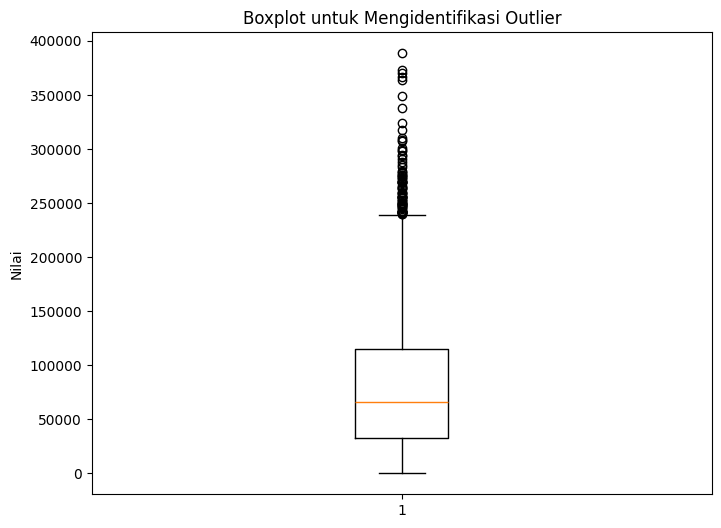

In [ ]:
#@title Template script untuk membuat boxplot dengan matplotlib

import matplotlib.pyplot as plt

# Misalkan df adalah dataframe Anda dan 'column' adalah kolom yang ingin divisualisasikan
plt.figure(figsize=(8,6))
plt.boxplot(dfclv['income'])
plt.title('Boxplot untuk Mengidentifikasi Outlier')
plt.ylabel('Nilai')
plt.show()

**D. Transformasi Data**
Transformasi data adalah proses mengubah data asli menjadi format yang lebih sesuai untuk analisis atau pemodelan. Langkah ini penting dalam data preprocessing karena dapat meningkatkan kinerja model machine
learning, mengurangi bias, dan memastikan bahwa data memenuhi asumsi yang diperlukan oleh algoritma tertentu. Transformasi data melibatkan berbagai teknik seperti normalisasi, standardisasi, penskalaan fitur,
dan transformasi non-linear yang dapat disesuaikan dengan karakteristik data dan tujuan analisis.


In [ ]:
dfclv[['income','purchases','days_on_platform']].skew()

,0
income,1.027242
purchases,1.086943
days_on_platform,1.025915


**D.1 Normalisasi Data**

Normalisasi data adalah proses mengubah skala data sehingga semua fitur berada dalam rentang yang sama. Teknik ini sering digunakan ketika fitur memiliki skala yang berbeda dan algoritma yang sensitif terhadap skala
data, seperti K-Nearest Neighbors (KNN) atau Neural Networks, akan diterapkan.

**D.1.1 Min-Max Scaling**

Min-Max Scaling digunakan untuk mengubah skala data sehingga setiap fitur berada dalam rentang tertentu, biasanya antara 0 dan 1. Metode ini mempertahankan hubungan proporsional antar nilai data.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data memiliki distribusi yang tidak terlalu skewed.
* Algoritma yang digunakan sensitif terhadap skala data, seperti KNN atau Neural Networks.
* Ingin mempertahankan hubungan proporsional antar nilai data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("Skewness awal:", dfclv['income'].skew())

Skewness awal: 1.0272424013453245


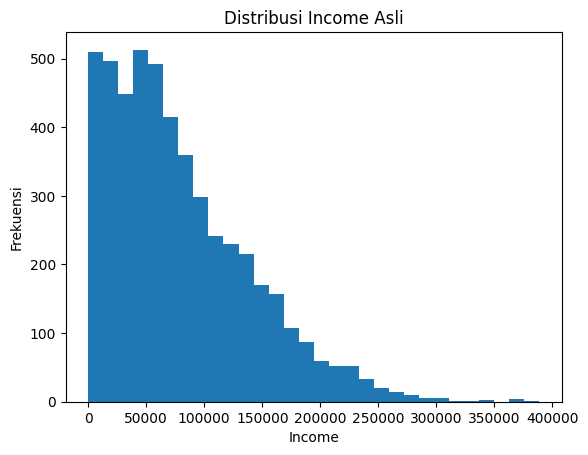

In [ ]:
plt.figure()
plt.hist(dfclv['income'], bins=30)
plt.title('Distribusi Income Asli')
plt.xlabel('Income')
plt.ylabel('Frekuensi')
plt.show()

Perbandingan Income Sebelum dan Sesudah Scaling:

   income  income_scaled
0  126895       0.326561
1  161474       0.415551
2  104723       0.269500
3   43791       0.112688
4  132181       0.340164
5   12315       0.031683
6   51679       0.132988
7   53341       0.137266
8  129157       0.332382
9   76842       0.197747

Nilai minimum setelah scaling: 0.0
Nilai maksimum setelah scaling: 1.0


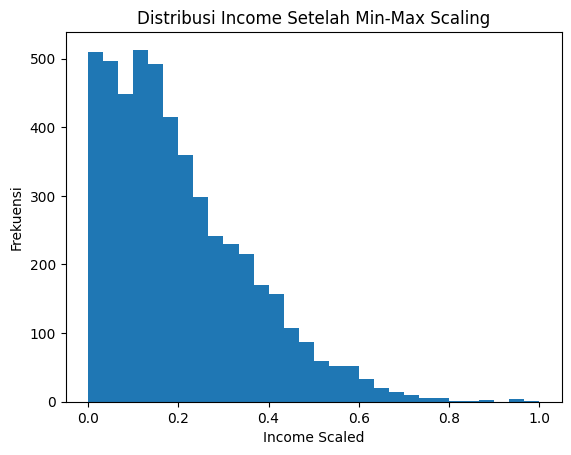

In [ ]:
# Copy dataframe to avoid overwriting original
df_scaled = dfclv.copy()

# Apply MinMax Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled['income_scaled'] = scaler.fit_transform(df_scaled[['income']])

# Show comparison (first 10 rows)
print("Perbandingan Income Sebelum dan Sesudah Scaling:\n")
print(df_scaled[['income', 'income_scaled']].head(10))

# Show min and max values
print("\nNilai minimum setelah scaling:", df_scaled['income_scaled'].min())
print("Nilai maksimum setelah scaling:", df_scaled['income_scaled'].max())

# Visualize distribution after scaling (single plot, no specific color)
plt.figure()
plt.hist(df_scaled['income_scaled'], bins=30)
plt.title("Distribusi Income Setelah Min-Max Scaling")
plt.xlabel("Income Scaled")
plt.ylabel("Frekuensi")
plt.show()

**D.1.2 Logarithmic Scaling**

Logarithmic Scaling mengubah skala data dengan mengambil logaritma dari setiap nilai. Metode ini efektif untuk data yang skewed dan membantu dalam mengurangi pengaruh outlier.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Data memiliki distribusi skewed ke kanan.
* Ingin mengurangi pengaruh outlier.
* Data memiliki nilai positif.


In [ ]:
#@title Template script untuk menerapkan Logarithmic Scaling dengan pandas dan numpy

# Misalkan df adalah dataframe Anda dan 'income' adalah kolom yang ingin ditransformasikan
dfclv['income_log'] = np.log1p(dfclv['income'])

print("Skewness setelah log:", dfclv['income_log'].skew())

Skewness setelah log: -1.584112636381647


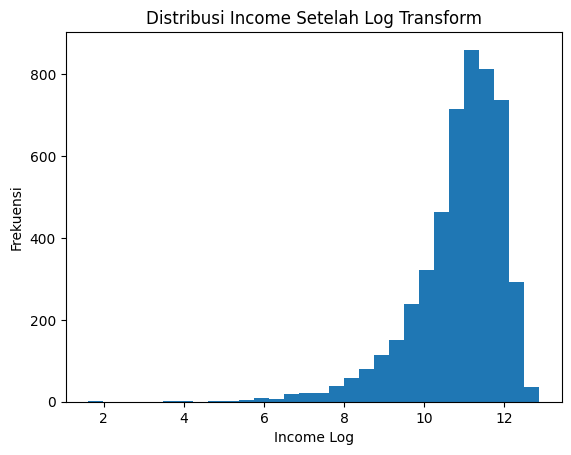

In [ ]:
plt.figure()
plt.hist(dfclv['income_log'], bins=30)
plt.title('Distribusi Income Setelah Log Transform')
plt.xlabel('Income Log')
plt.ylabel('Frekuensi')
plt.show()

**D.2 Standardisasi Data**

Standardisasi data adalah proses mengubah skala data sehingga setiap fitur memiliki mean nol dan standar deviasi satu. Teknik ini sering digunakan ketika algoritma memerlukan data terstandardisasi, seperti Logistic
Regression atau Support Vector Machines (SVM).

**D.2.1 Z-Score Standardization**

Z-Score Standardization mengubah data sehingga setiap fitur memiliki mean nol dan standar deviasi satu.
Metode ini memungkinkan perbandingan antar fitur yang berbeda skala.

**Kapan harus digunakan**

Metode ini paling sesuai digunakan ketika:
* Menggunakan algoritma yang sensitif terhadap skala data, seperti Logistic Regression atau SVM.
* Data memiliki distribusi yang mendekati normal.

Mean setelah standardisasi: -9.521272659185343e-17
Std setelah standardisasi: 1.0000000000000002


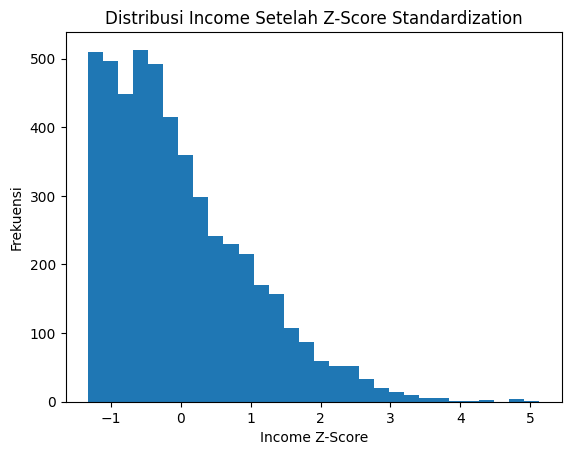

In [ ]:
#@title Template script untuk menerapkan Z-Score Standardization dengan pandas dan numpy

# Z-score manual
dfclv['income_zscore'] = (
    (dfclv['income'] - dfclv['income'].mean())
    / dfclv['income'].std()
)

print("Mean setelah standardisasi:", dfclv['income_zscore'].mean())
print("Std setelah standardisasi:", dfclv['income_zscore'].std())

plt.figure()
plt.hist(dfclv['income_zscore'], bins=30)
plt.title('Distribusi Income Setelah Z-Score Standardization')
plt.xlabel('Income Z-Score')
plt.ylabel('Frekuensi')
plt.show()

### **Tugas di Kelas (mini-project 20–30 menit) — *Dataset Bebas***

1.  **Cari dataset publik** (Kaggle / UCI / Google Dataset Search / data.go.id).
**Syarat:**
* ≥5 kolom
* Ada variabel numerik & kategorik
* Mengandung missing value atau potensi outlier

2. **Load data** ke DataFrame `df`

3. **Identifikasi Struktur Data**

* Observation (satu baris mewakili apa?)
* Variabel numerik
* Variabel kategorik

4. **Periksa Missing values**
* Hitung jumlah missing per kolom
* Pilih salah satu: hapus atau imputasi
* Jelaskan alasan keputusan

5. **Deteksi Outlier**

* Pilih satu variabel numerik utama
* Gunakan boxplot atau metode lain
* Tentukan apakah ada outlier
* Jelaskan apakah outlier dihapus atau dipertahankan


6. **Transformasi Data**
*  Lakukan minimal satu transformasi pada variabel numerik
* Bandingkan distribusi sebelum dan sesudah transformasi.

7. **Penjelasan singkat**

---

### **Output**

1. Tabel ringkasan missing
2. Bukti deteksi outlier
3. Grafik sebelum/sesudah transformasi
4. Interpretasi singkat

